# MoS2 reconstruction in quantem 

Notebook from Georgios Varnavides and Stephanie Ribet

Data from Atom-by-atom Imaging of Moiré Phasons using Electron Ptychography


In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import numpy as np

import quantem as em
from quantem.core import config
from quantem.core.visualization import show_2d
import matplotlib.pyplot as plt
config.set_device(0)
print(config.get("device"))

/home/sribet/micromamba/envs/quantem/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda:0


# load data

In [3]:
file_data = "/data1/steph/quantem_dev/data/Figure 4/scan_x128_y128.raw"

data = np.fromfile(
    file_data, 
    dtype='float32'
)

In [4]:
(data.shape[0]/130/128)**0.5

128.0

In [5]:
dim = 128
dc = em.datastructures.Dataset4dstem.from_array(
    array = np.clip(
        np.flip(np.reshape(data,(dim,dim,130,128))[1:-1,1:-1,5:-5,4:-4],axis=3), 0, np.inf)
)

(<Figure size 800x400 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

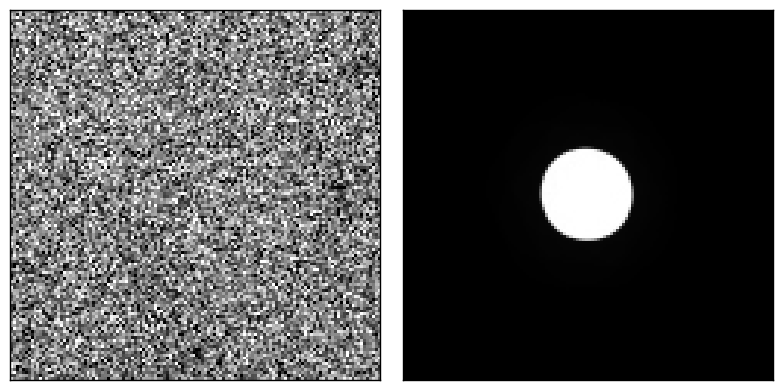

In [6]:
show_2d(
  [
      dc.array.sum((-1,-2)),
      dc.array.sum((0,1))
  ]
)

In [7]:
# calibrations
PROBE_SEMIANGLE = 25
ENERGY = 80e3
STEP_SIZE = 0.43

In [8]:
# bin data
# dc.bin(2, axes= (2,3), modify_in_place=True)

In [9]:
dc.array.shape

(126, 126, 120, 120)

# calibrate

In [10]:
dc.get_dp_mean()

Dataset(shape=(120, 120), dtype=float32, name='4D-STEM dataset_dp_mean')
  sampling: [1. 1.]
  units: ['pixels', 'pixels']
  signal units: 'arb. units'

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

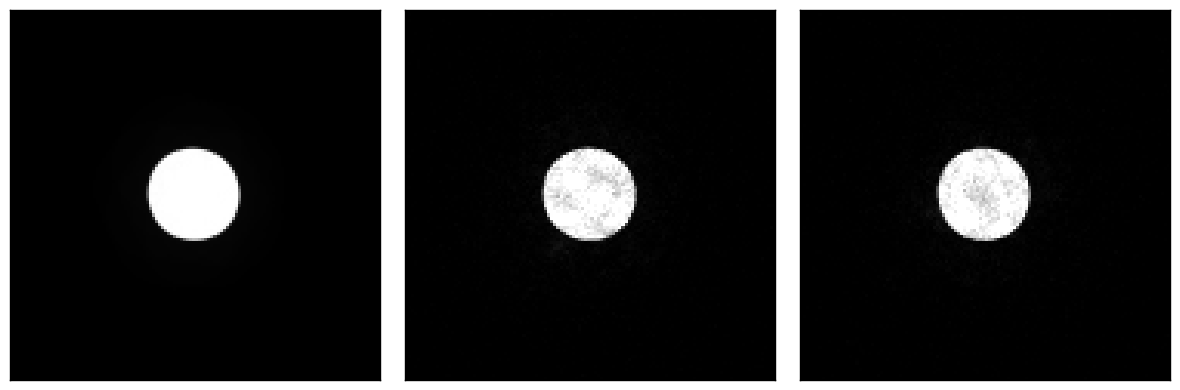

In [11]:
em.visualization.show_2d(
    [
        dc.dp_mean,
        dc.array[30,30],
        dc.array[15,15]
    ]
)

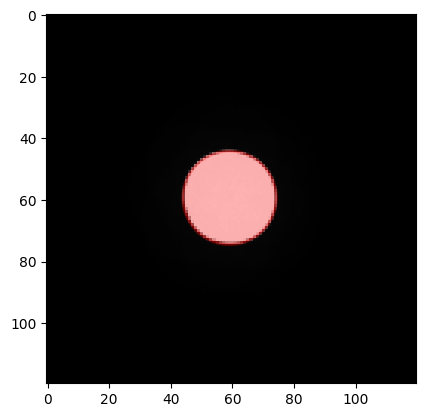

quantem Dataset named '4D-STEM dataset'
  shape: (126, 126, 120, 120)
  dtype: float32
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [0.43       0.43       1.64194258 1.64194258]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'


In [12]:
from quantem.core.utils.diffractive_imaging_utils import fit_probe_circle
probe_qy0, probe_qx0, probe_R = fit_probe_circle(dc.dp_mean.array, show=True)
dc.sampling[2] = PROBE_SEMIANGLE / probe_R
dc.sampling[3] = PROBE_SEMIANGLE / probe_R
dc.units[2:] = ["mrad", "mrad"]


dc.sampling[0] = STEP_SIZE
dc.sampling[1] = STEP_SIZE
dc.units[0:2] = ["A", "A"]


print(dc)

In [13]:
from quantem.core.datastructures import Dataset4dstem
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.ptychography_lite import PtychoLite, PtychoLiteDIP

Forcing best fit rotation to 183 degrees.
Forcing transpose of intensities to False.


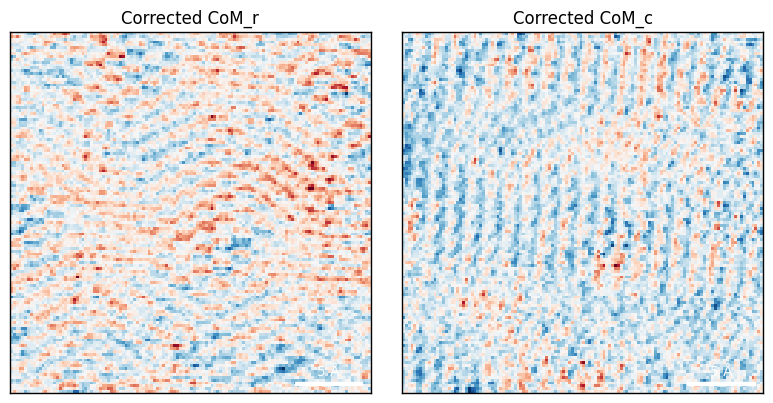

Normalizing intensities: 100%|█| 15876/15876 [00:11<00:00, 1355.91probe position


In [32]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dc)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
    probe_energy=ENERGY,
    force_com_rotation=183,
    force_com_transpose = False,
)


In [47]:
ptycho_pix = PtychoLite.from_dataset(
    dset=pdset,
    num_slices=10,
    obj_type="potential",
    num_probes=6,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    obj_padding_px=(64,64),
    device="cpu",
    polar_parameters = {
        'C10': 93,
        'C12': 11.988049507141113, 'phi12': 0.015169759280979633
    },
    middle_focus=True,
    slice_thicknesses=15,
    log_dir = "./logs",
    log_prefix="zondag_mos2",
    log_images_every=5,
    log_probe_images=False,
)

Logging to logs/zondag_mos2_20251214_070812_pix


Iter 10/10, Loss: 3.756e+02: 100%|██████████████| 10/10 [01:32<00:00,  9.27s/it]


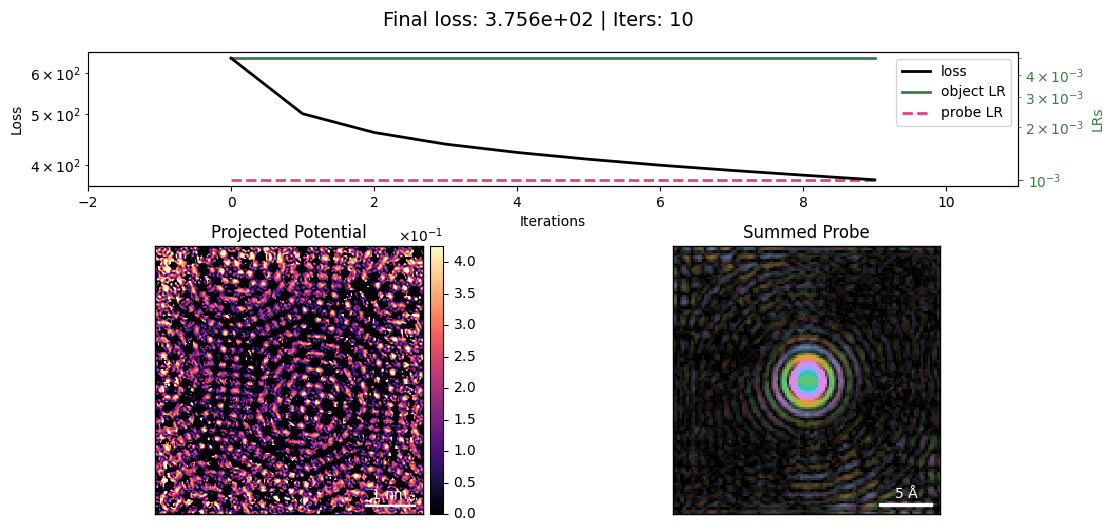

In [48]:
constraints = {
    "object":{
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor":0.01,
        # "tv_weight_z": 1000,
        # "positivity": True,
        "identical_slices":True
        # "q_lowpass": 1.8,
        # "q_highpass": 0.05
        
    },
    # "probe":{
    #     "center_probe":False
        
    # }
}
ptycho_pix.reconstruct(
    num_iters=10, 
    device="gpu", 
    batch_size=512,
    constraints=constraints,
    reset = True,
).visualize()


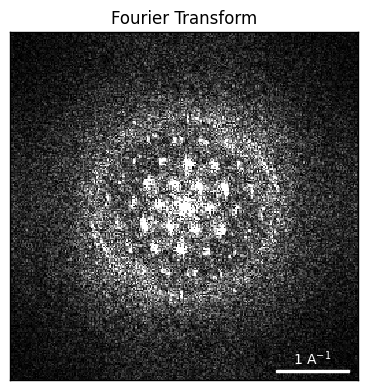

In [52]:
ptycho_pix.show_obj_fft()

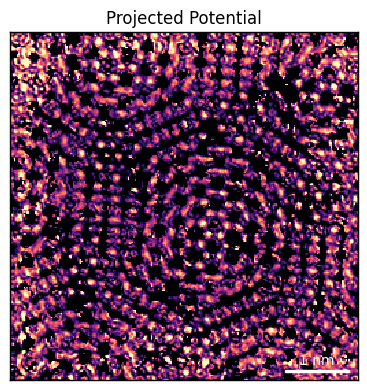

In [53]:
ptycho_pix.show_obj()

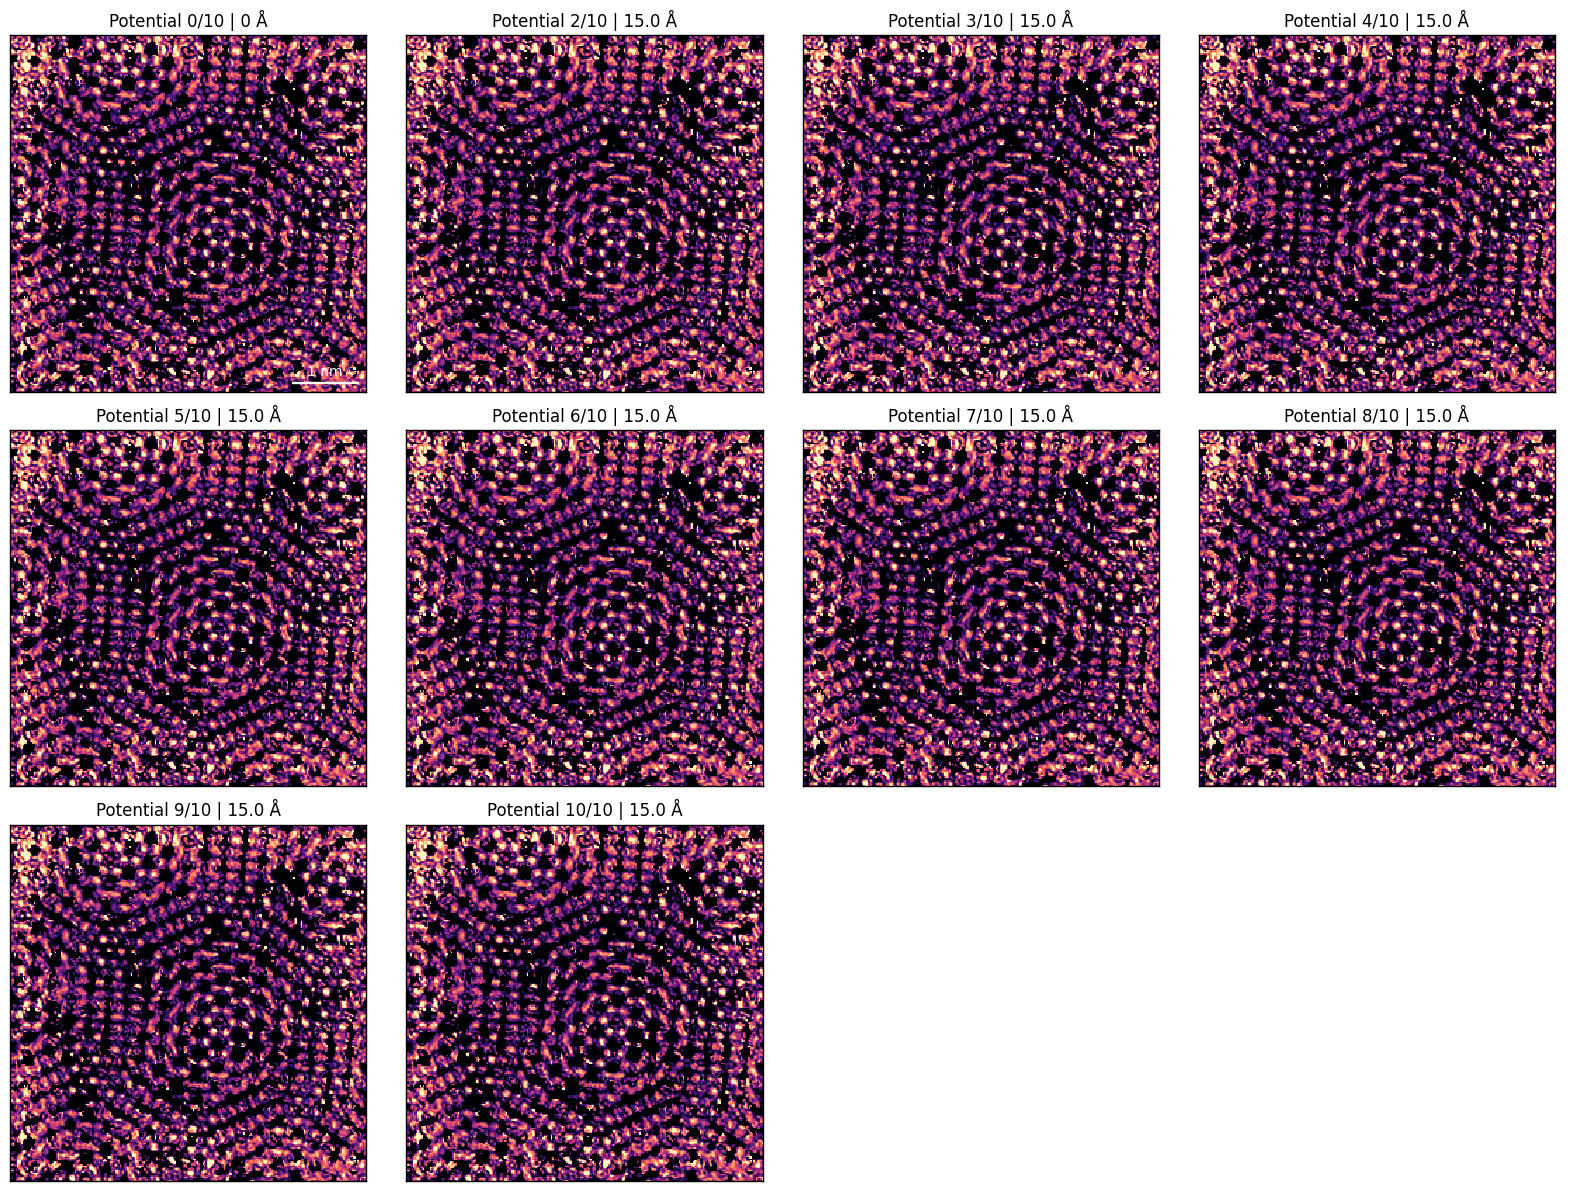

In [54]:
ptycho_pix.show_obj_slices()

Iter 500/500, Loss: 1.330e-04, : 100%|████████| 500/500 [00:11<00:00, 43.72it/s]


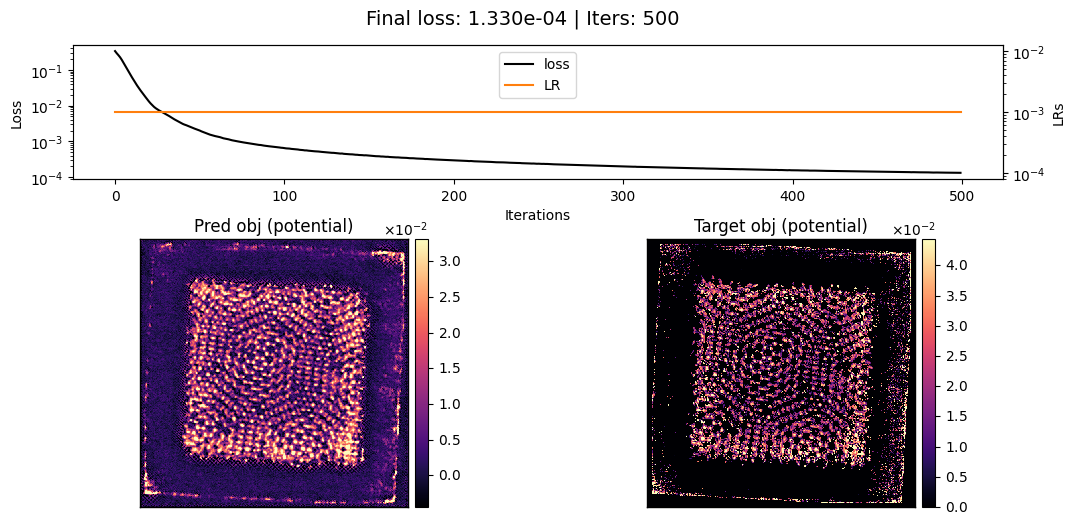

Iter 500/500, Loss: 3.643e-01, : 100%|████████| 500/500 [00:30<00:00, 16.13it/s]


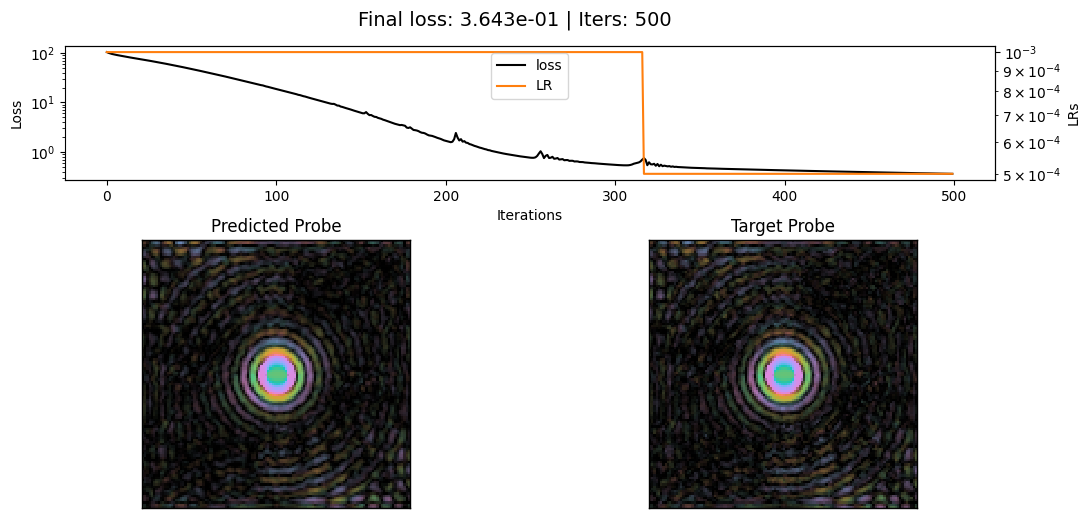

In [56]:
ptycho_dip = PtychoLiteDIP.from_ptycholite(
    ptycholite=ptycho_pix,
    pretrain_iters=500,
    device='gpu',
    # pretrain_object=False,
)

In [57]:
import gc
import torch 

torch.cuda.empty_cache()
gc.collect()

60630

Iter 10/10, Loss: 2.750e+02: 100%|██████████████| 10/10 [01:48<00:00, 10.87s/it]


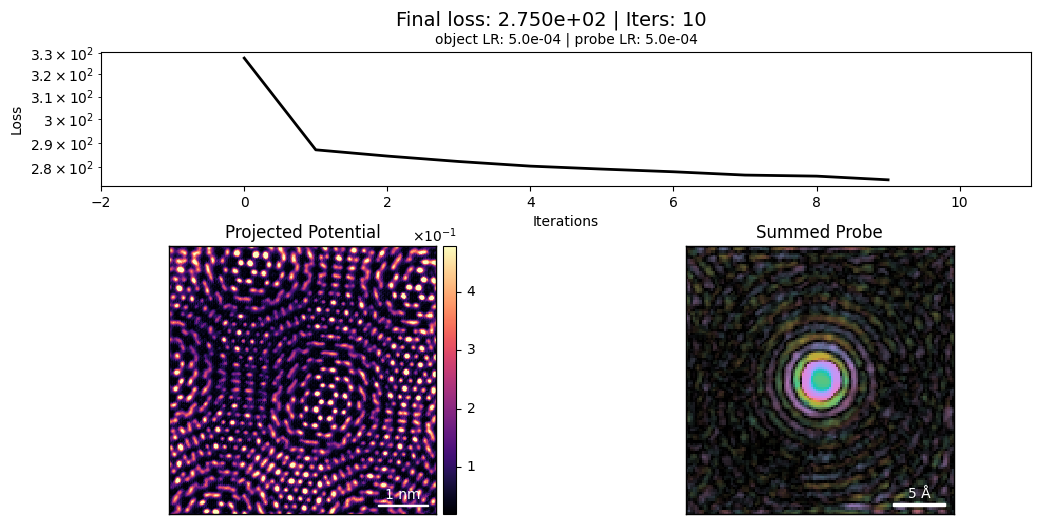

In [68]:

constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -1,
        # "tv_weight_z": 1000,
        # "positivity": False,
        "identical_slices":True,
        # "q_lowpass": 1.8,
        # "q_highpass": 0.05
        
    }
}
ptycho_dip.reconstruct(
    num_iters=10, 
    reset=True, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
).visualize()


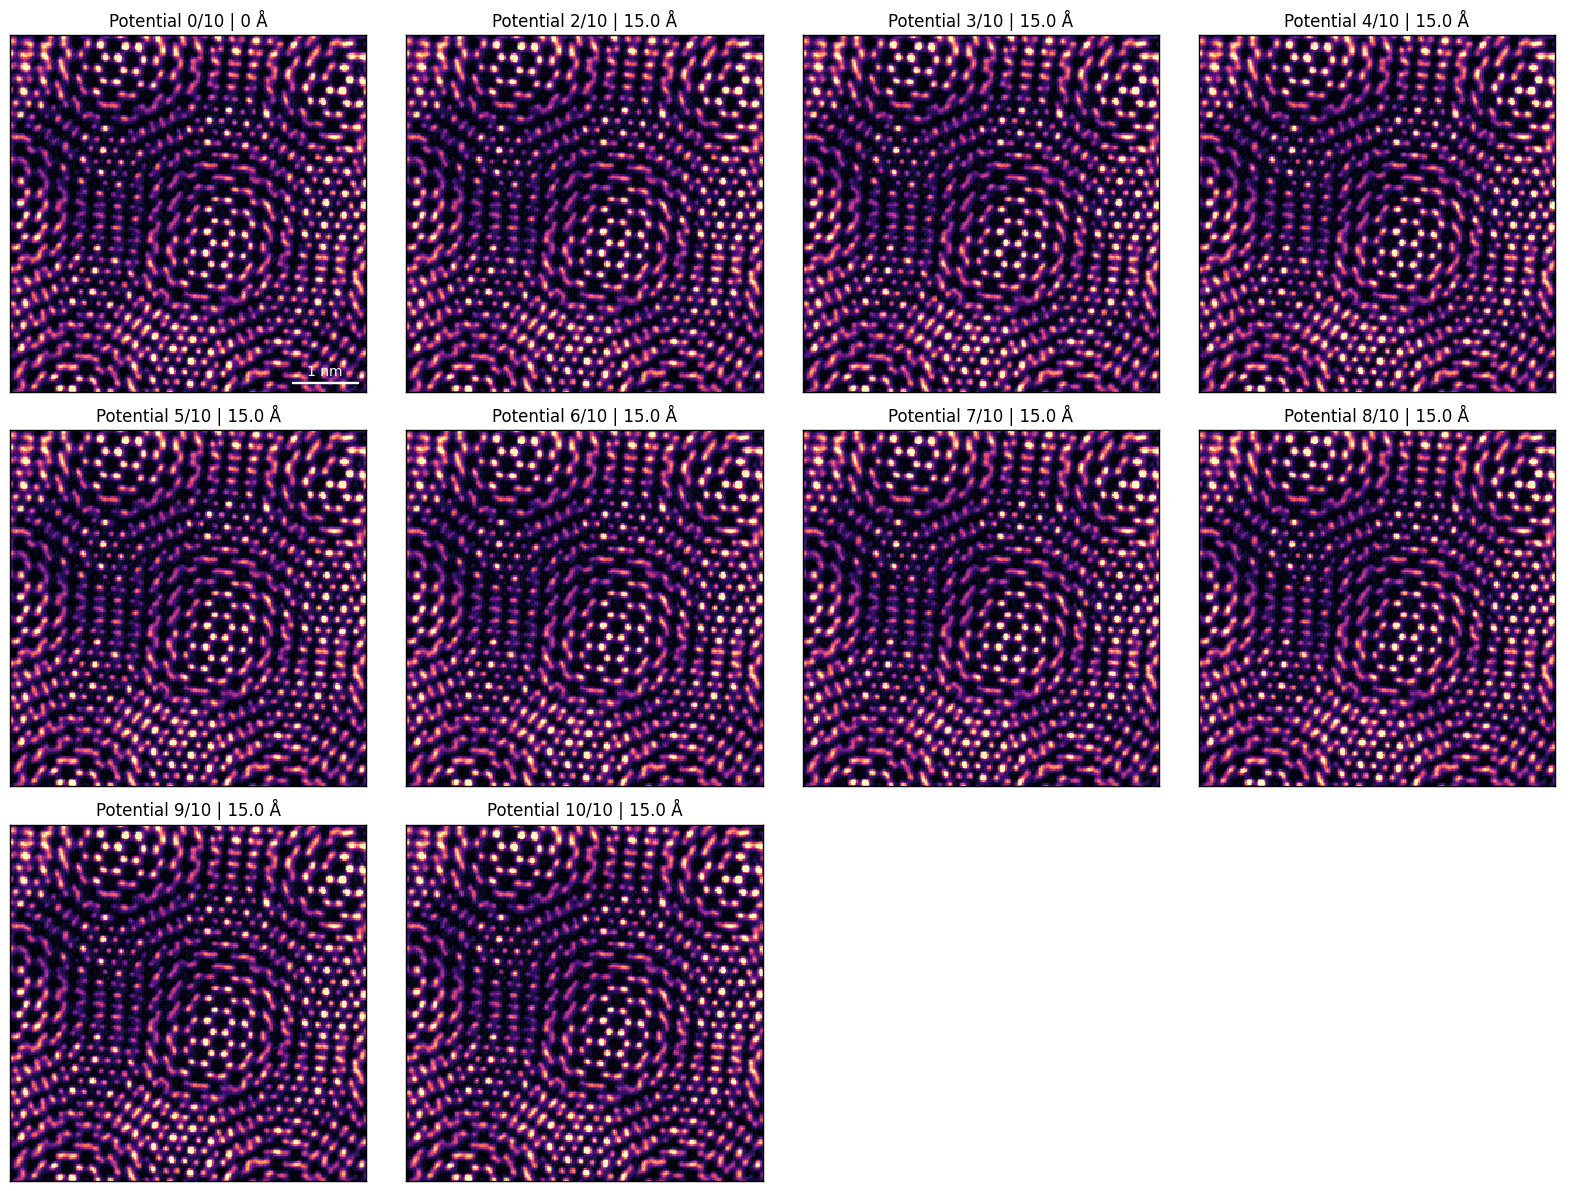

In [69]:
ptycho_dip.show_obj_slices()

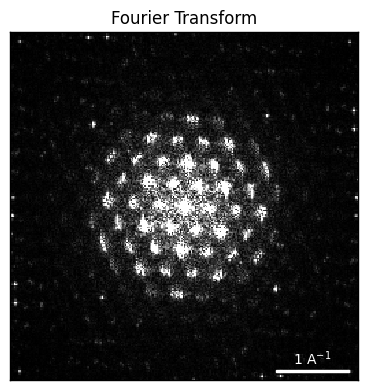

In [74]:
ptycho_dip.show_obj_fft()

Iter 10/10, Loss: 2.716e+02: 100%|██████████████| 10/10 [01:48<00:00, 10.83s/it]


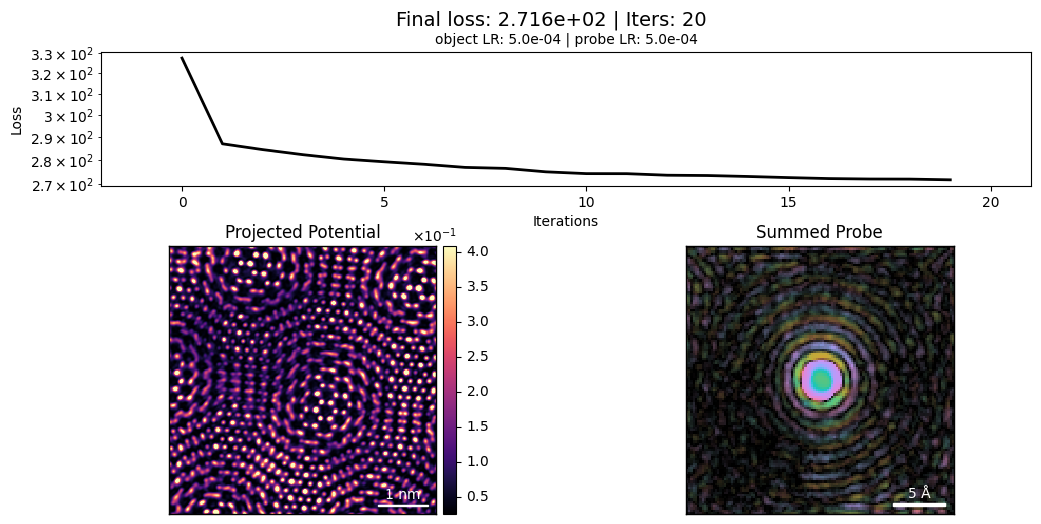

In [75]:

constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -1,
        # "tv_weight_z": 1000,
        # "positivity": False,
        "identical_slices":True,
        "q_lowpass": 1.3,
        # "q_highpass": 0.05
        
    }
}
ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
).visualize()


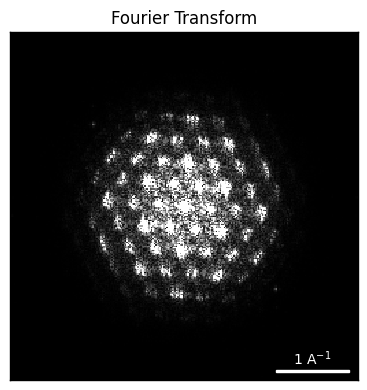

In [76]:
ptycho_dip.show_obj_fft()

Iter 10/10, Loss: 2.695e+02: 100%|██████████████| 10/10 [01:48<00:00, 10.81s/it]


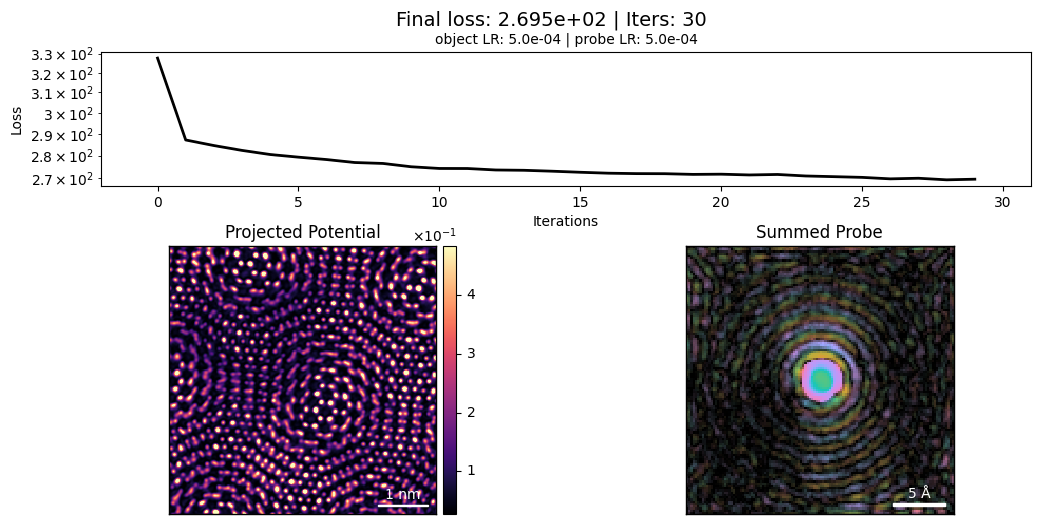

In [77]:

constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -0.5,
        # "tv_weight_z": 1000,
        # "positivity": False,
        "identical_slices":True,
        "q_lowpass": 1.4,
        # "q_highpass": 0.05
        
    }
}
ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
).visualize()


Iter 10/10, Loss: 2.670e+02: 100%|██████████████| 10/10 [01:48<00:00, 10.86s/it]


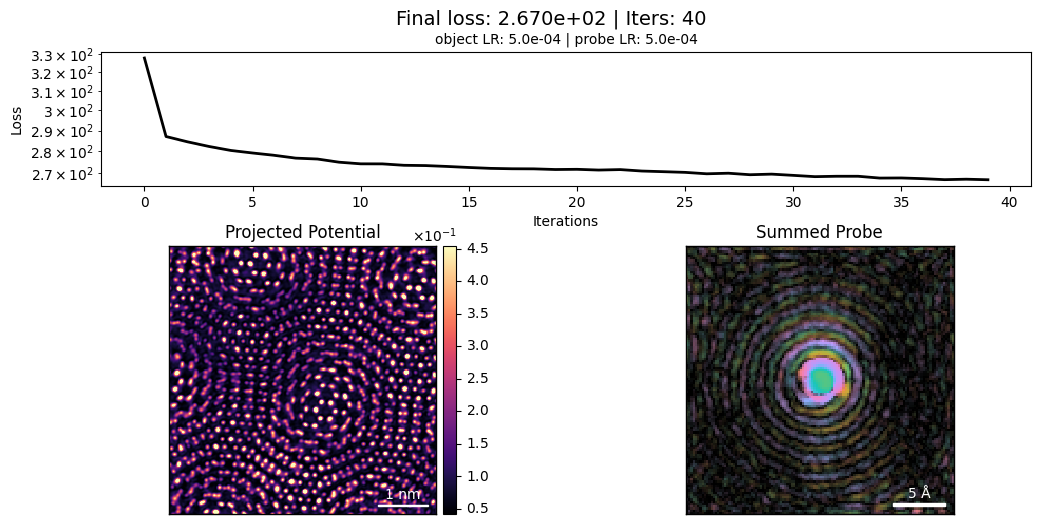

In [90]:

constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -0.5,
        # "tv_weight_z": 1000,
        # "positivity": False,
        "identical_slices":True,
        "q_lowpass": 1.5,
        # "q_highpass": 0.05
        
    }
}
ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
).visualize()


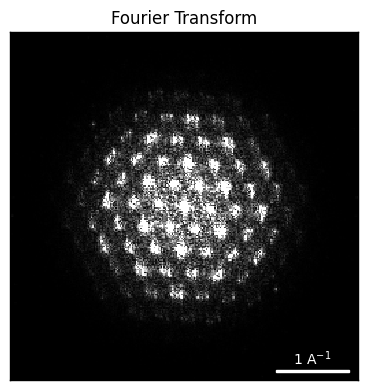

In [91]:
ptycho_dip.show_obj_fft()

Iter 10/10, Loss: 2.659e+02: 100%|██████████████| 10/10 [01:48<00:00, 10.88s/it]


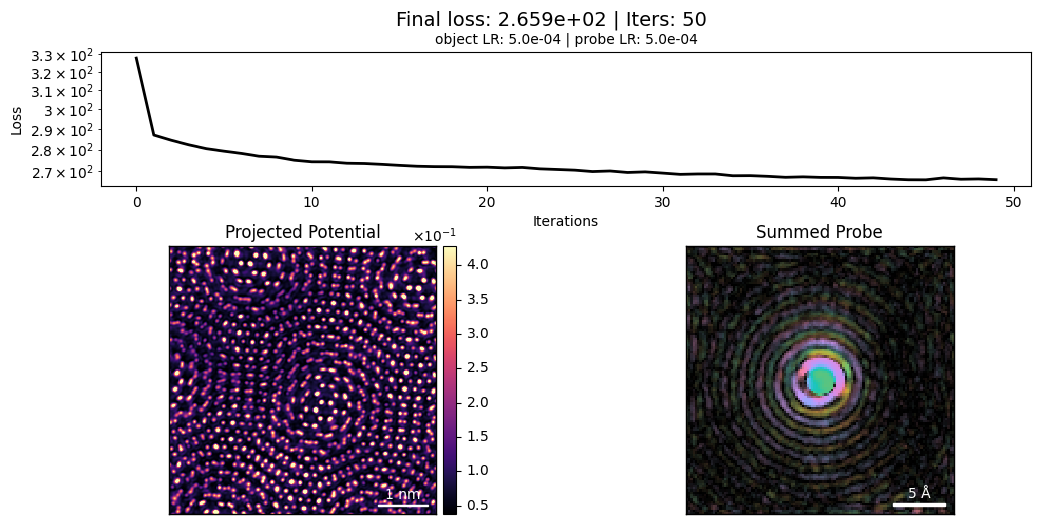

In [95]:

constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -0.5,
        # "tv_weight_z": 1000,
        # "positivity": False,
        "identical_slices":True,
        "q_lowpass": 1.5,
        # "q_highpass": 0.05
        
    }
}
ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
).visualize()


Iter 10/10, Loss: 2.646e+02: 100%|██████████████| 10/10 [01:48<00:00, 10.88s/it]


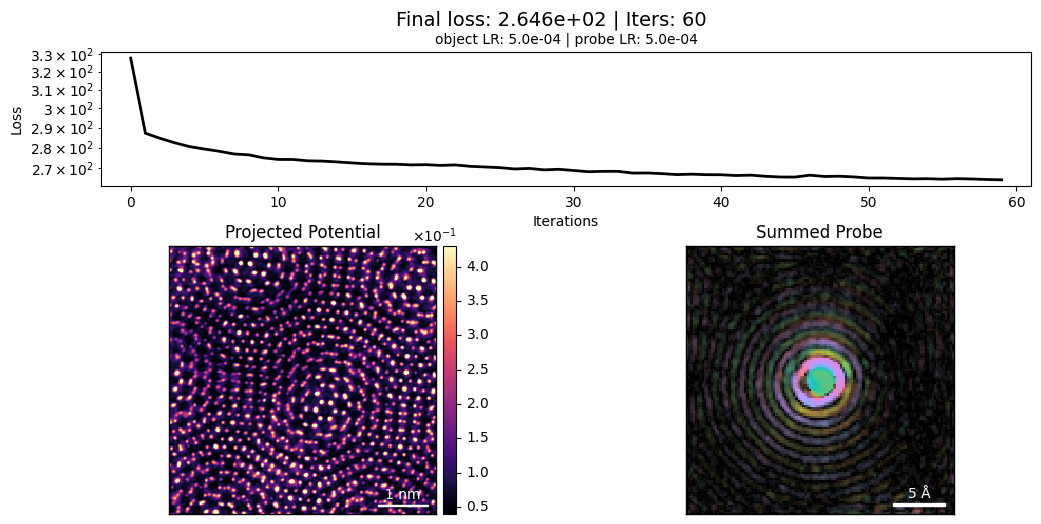

In [100]:

constraints = {
    "object":{
        "fix_potential_baseline": False,
        "fix_potential_baseline_factor": -0.5,
        # "tv_weight_z": 1000,
        # "positivity": False,
        "identical_slices":True,
        "q_lowpass": 1.6,
        # "q_highpass": 0.05
        
    }
}
ptycho_dip.reconstruct(
    num_iters=10, 
    reset=False, 
    scheduler_type='plateau', 
    batch_size=512,
    constraints=constraints
).visualize()


1


(<Figure size 1200x1200 with 4 Axes>,
 array([[<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>],
        [<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>]], dtype=object))

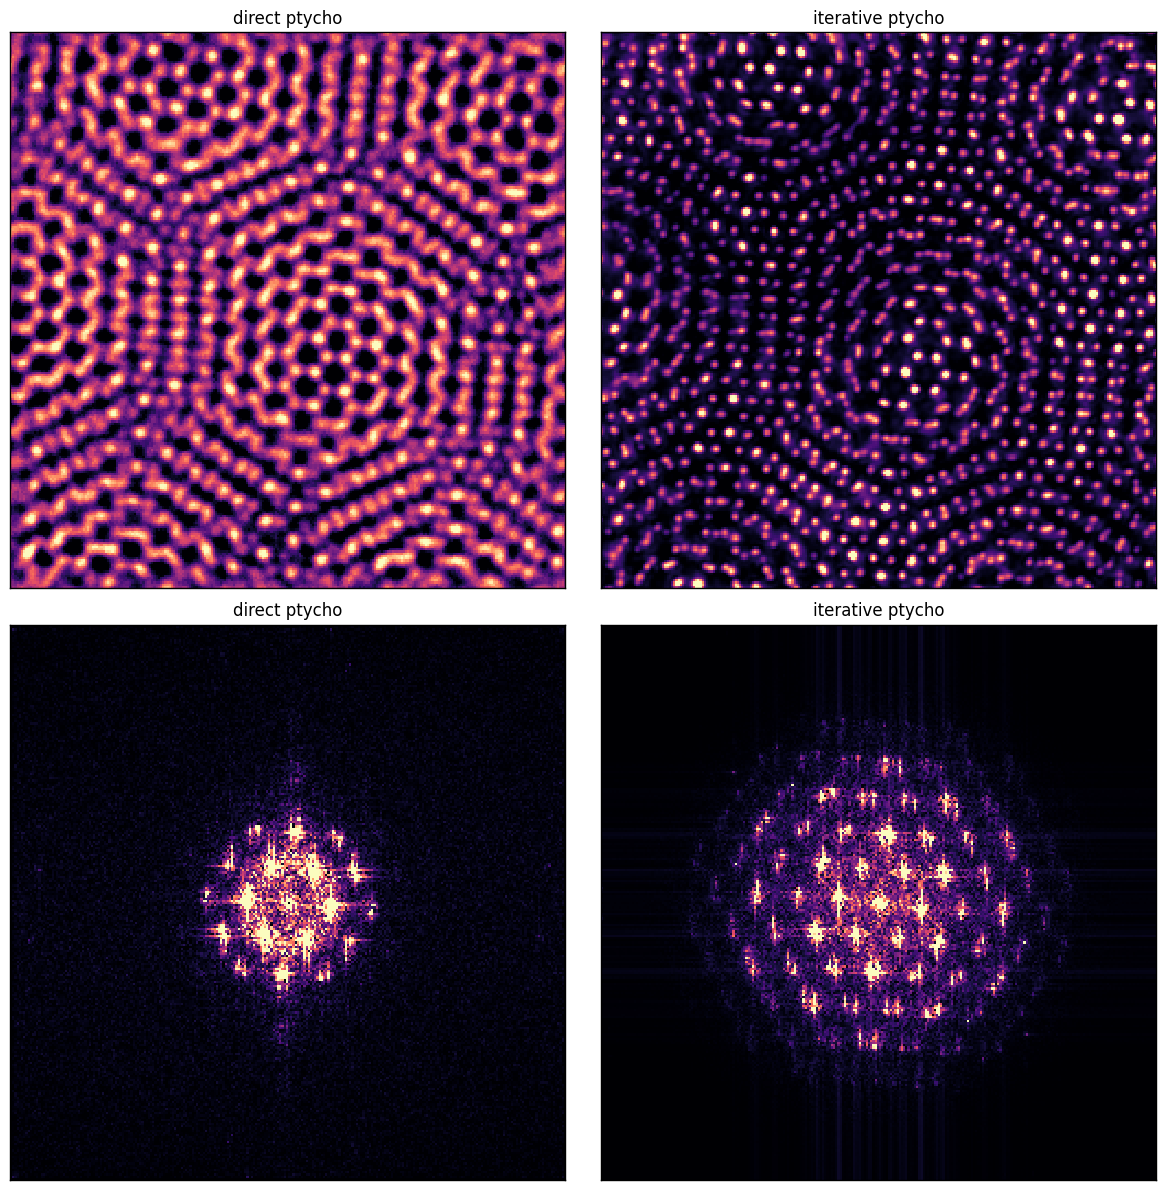

In [101]:
def fft(array):
    return np.abs(np.fft.fftshift(np.fft.fft2(array)))

norm = em.visualization.NormalizationConfig(
    lower_quantile=0.1,
    upper_quantile=0.99
)
 

pad = (ptycho_dip.obj_cropped.shape[1] - initial_parallax.obj.shape[0])//2
print(pad)
show_2d(
    [[
        initial_parallax.obj,
        ptycho_dip.obj_cropped.sum(0),
    ],

    [
        np.pad(
            fft(initial_parallax.obj),
            (
                (pad, pad),
                (pad, pad)
            )
        ),
        fft(ptycho_dip.obj_cropped.sum(0)),
    ]],
    cmap = "magma",
    title = ["direct ptycho", "iterative ptycho"],
    # minmax = None,
    axsize = (6,6),
    norm = [norm, norm]
)

100%|██████████████████████████████████████| 703/703 [00:00<00:00, 52177.38it/s]


(<Figure size 400x400 with 1 Axes>, <Axes: >)

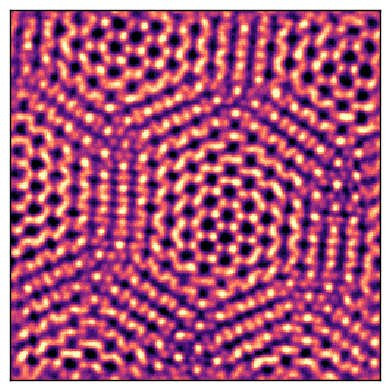

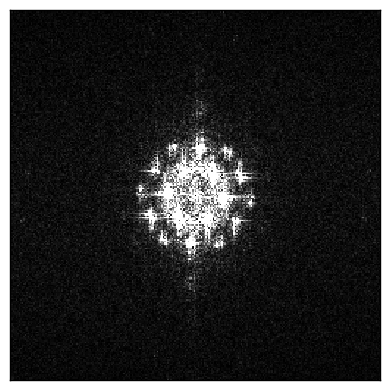

In [96]:
direct_ptycho = em.diffractive_imaging.direct_ptychography.DirectPtychography.from_dataset4d(
    dc,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    aberration_coefs={'C10':93}, # start close to focus
    device="gpu",
    rotation_angle=np.deg2rad(183), # known rotation
    max_batch_size=32
)

initial_parallax = direct_ptycho.reconstruct(
    upsampling_factor = 2,
    deconvolution_kernel='quadratic',
    max_batch_size = 32
)

show_2d(initial_parallax.obj, cmap = "magma")


show_2d(np.fft.fftshift(np.abs(np.fft.fft2(initial_parallax.obj))))

1


(<Figure size 1200x1200 with 4 Axes>,
 array([[<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>],
        [<Axes: title={'center': 'direct ptycho'}>,
         <Axes: title={'center': 'iterative ptycho'}>]], dtype=object))

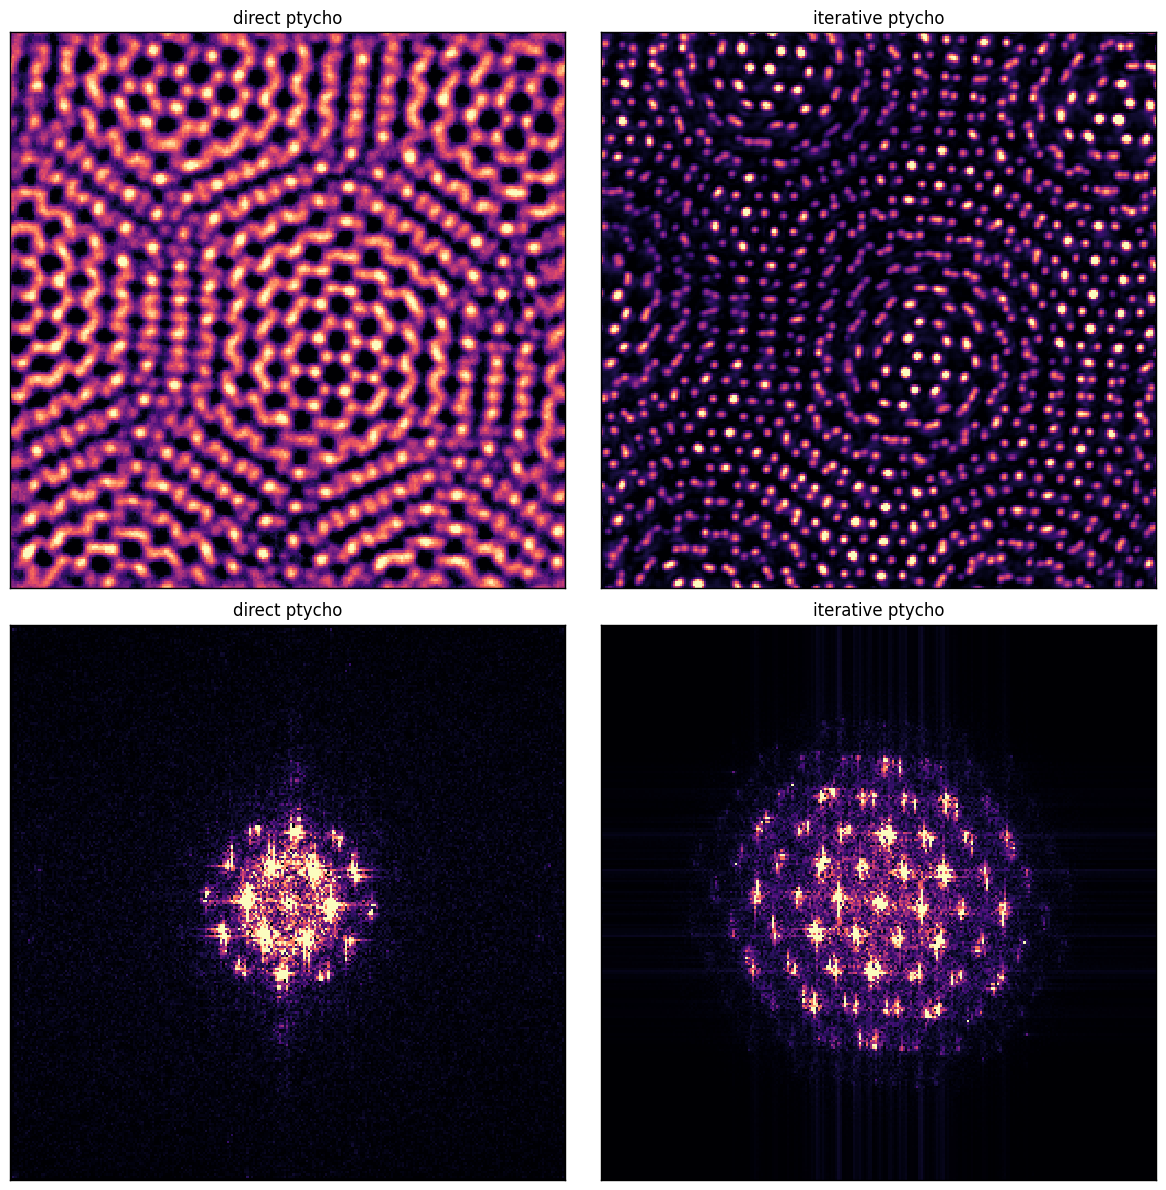

In [97]:
def fft(array):
    return np.abs(np.fft.fftshift(np.fft.fft2(array)))

norm = em.visualization.NormalizationConfig(
    lower_quantile=0.1,
    upper_quantile=0.99
)
 

pad = (ptycho_dip.obj_cropped.shape[1] - initial_parallax.obj.shape[0])//2
print(pad)
show_2d(
    [[
        initial_parallax.obj,
        ptycho_dip.obj_cropped.sum(0),
    ],

    [
        np.pad(
            fft(initial_parallax.obj),
            (
                (pad, pad),
                (pad, pad)
            )
        ),
        fft(ptycho_dip.obj_cropped.sum(0)),
    ]],
    cmap = "magma",
    title = ["direct ptycho", "iterative ptycho"],
    # minmax = None,
    axsize = (6,6),
    norm = [norm, norm]
)

In [98]:
import h5py
from datetime import datetime

savedir = "recons"

now = datetime.now().strftime("%y%m%d_%H%M")

In [102]:
# Save direct version
with h5py.File(f"{savedir}/{now}_mos2_ptycho_direct.h5", 'w') as f:
    print(f)
    f.create_dataset('obj_cropped', data=initial_parallax.obj, compression='gzip')


# Save pixelated version
with h5py.File( f"{savedir}/{now}_mos2_ptycho_pix.h5", 'w') as f:
    print(f)
    f.create_dataset('obj_cropped', data=ptycho_pix.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_pix.probe, compression='gzip')
    f.attrs['model_type'] = 'pixelated'

# Save dgp version
with h5py.File(f"{savedir}/{now}_mos2_ptycho_dip.h5", 'w') as f:
    f.create_dataset('obj_cropped', data=ptycho_dip.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_dip.probe, compression='gzip')
    f.attrs['model_type'] = 'dgp'

<HDF5 file "251214_1127_mos2_ptycho_direct.h5" (mode r+)>
<HDF5 file "251214_1127_mos2_ptycho_pix.h5" (mode r+)>


In [103]:
# Save dgp version
with h5py.File(f"{savedir}/{now}_mos2_ptycho_dip.h5", 'w') as f:
    f.create_dataset('obj_cropped', data=ptycho_dip.obj_cropped, compression='gzip')
    f.create_dataset('probe', data=ptycho_dip.probe, compression='gzip')
    f.attrs['model_type'] = 'dgp'

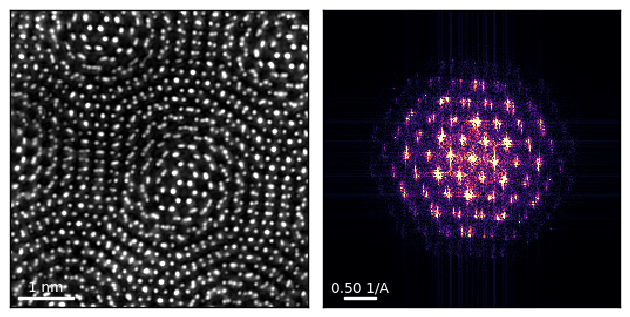

In [105]:
fig, ax = plt.subplots(1,2)

em.visualization.show_2d(
      ptycho_dip.obj_cropped.sum(0),
      figax = (fig, ax[0]), 
      scalebar = {
        'sampling':ptycho_dip.sampling[0]/10,
        'units':'nm',
        'length':1,
        'loc':3,   
    }
)


em.visualization.show_2d(
      fft(ptycho_dip.obj_cropped.sum(0)),
      figax = (fig, ax[1]), 
      scalebar = {
        'sampling':np.fft.fftfreq(ptycho_dip.obj_cropped.shape[1],ptycho_dip.sampling[0])[1],
        'units':'1/A',
        'length':0.5,
        'loc':3,   
     },
     norm = norm,
      cmap = "magma"
)


plt.savefig('mos2_iterative_calibration.pdf', bbox_inches = "tight")